# Notebook 02 — Análisis Exploratorio de Datos (EDA)

## Objetivo

El EDA responde las preguntas fundamentales antes de modelar:

1. ¿Está balanceado el target? ¿Cambia el balance según el período?
2. ¿Cómo evolucionan las features a lo largo del tiempo? ¿Hay patrones visuales?
3. ¿Hay correlación entre las features y el target? ¿Y entre features entre sí?

El EDA **no toma decisiones de modelado**, pero informa las decisiones que tomamos después: qué features incluir, qué regularización usar, si hay outliers extremos que tratar.

**Input**: `data/processed/sp500_features.csv` generado por el notebook 01.

In [ ]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src import utils

utils.set_plot_style()

# Cargar features procesadas
df = pd.read_csv("../data/processed/sp500_features.csv", index_col=0, parse_dates=True)
print(f"Dataset cargado: {df.shape} | {df.index[0].date()} → {df.index[-1].date()}")

FEATURE_COLS = ["RSI_14", "MACD", "BB_position", "return_1d", "return_5d",
                "volume_change", "vix", "t10y2y", "fedfunds", "cpi", "unrate"]

Dataset cargado: (4643, 17) | 2008-01-02 → 2026-06-16


## Distribución del target

Un target desbalanceado puede hacer que un modelo naive (siempre predice la clase mayoritaria) tenga accuracy engañosamente alta. Por eso necesitamos:
1. Conocer la proporción exacta de la clase positiva (mercado sube)
2. Ver si el balance varía por período — un año de crisis puede tener más días bajistas
3. Definir la estrategia de manejo del desbalance

Con ~54.5% de días positivos el desbalance es **leve** — no necesitamos SMOTE ni undersampling. Alcanza con `class_weight='balanced'` en Logistic Regression y `scale_pos_weight` en XGBoost.

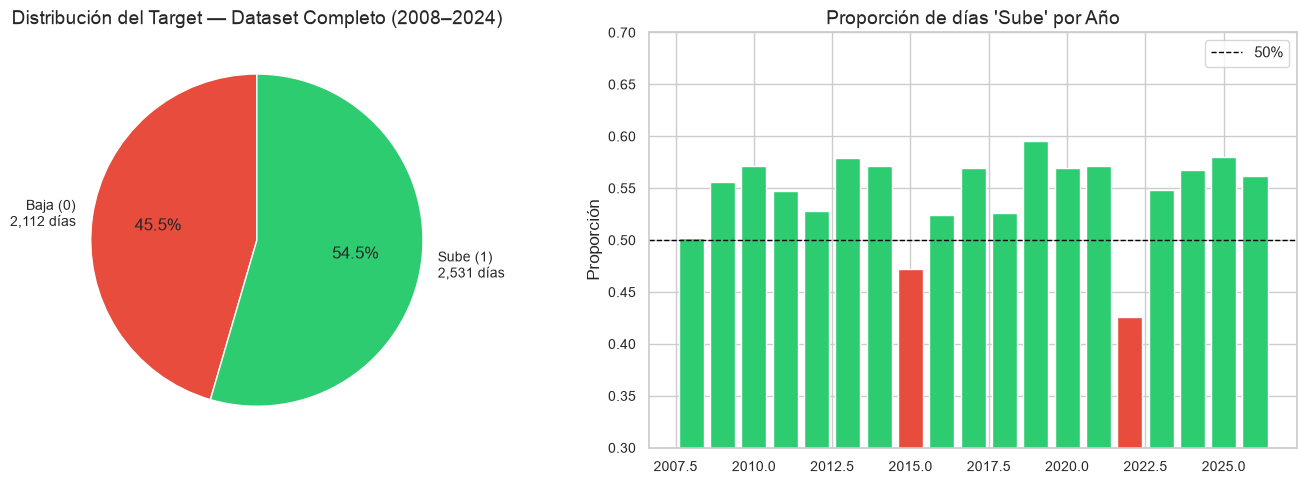


Balance global: 54.5% días positivos
Años con mayoría bajista: [2015, 2022]


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución global
conteo = df["target"].value_counts()
axes[0].pie(
    [conteo[0], conteo[1]],
    labels=[f"Baja (0)\n{conteo[0]:,} días", f"Sube (1)\n{conteo[1]:,} días"],
    colors=["#e74c3c", "#2ecc71"],
    autopct="%1.1f%%",
    startangle=90,
)
axes[0].set_title("Distribución del Target — Dataset Completo (2008–2024)")

# Proporción por año
prop_año = df.groupby(df.index.year)["target"].mean()
colores = ["#e74c3c" if v < 0.5 else "#2ecc71" for v in prop_año.values]
axes[1].bar(prop_año.index, prop_año.values, color=colores)
axes[1].axhline(0.5, color="black", linestyle="--", linewidth=1, label="50%")
axes[1].set_title("Proporción de días 'Sube' por Año")
axes[1].set_ylabel("Proporción")
axes[1].set_ylim(0.3, 0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nBalance global: {conteo[1]/len(df)*100:.1f}% días positivos")
print(f"Años con mayoría bajista: {list(prop_año[prop_año < 0.5].index)}")

## Series temporales de precios e indicadores

Visualizamos la evolución temporal de los features más relevantes junto con el precio del S&P 500. Esto permite:
- Identificar regímenes de mercado (crisis, bull market, alta volatilidad)
- Ver cómo reaccionan los indicadores en momentos extremos (GFC 2008-09, COVID 2020)
- Detectar si alguna feature tiene comportamiento no-estacionario que requiera transformación

Marcamos tres regímenes históricos:
- **GFC 2008-09**: Crisis Financiera Global — mercado cae ~57%
- **Bull Market 2013-2019**: mercado sube continuamente con baja volatilidad
- **COVID 2020**: caída del 34% en 33 días, recuperación récord

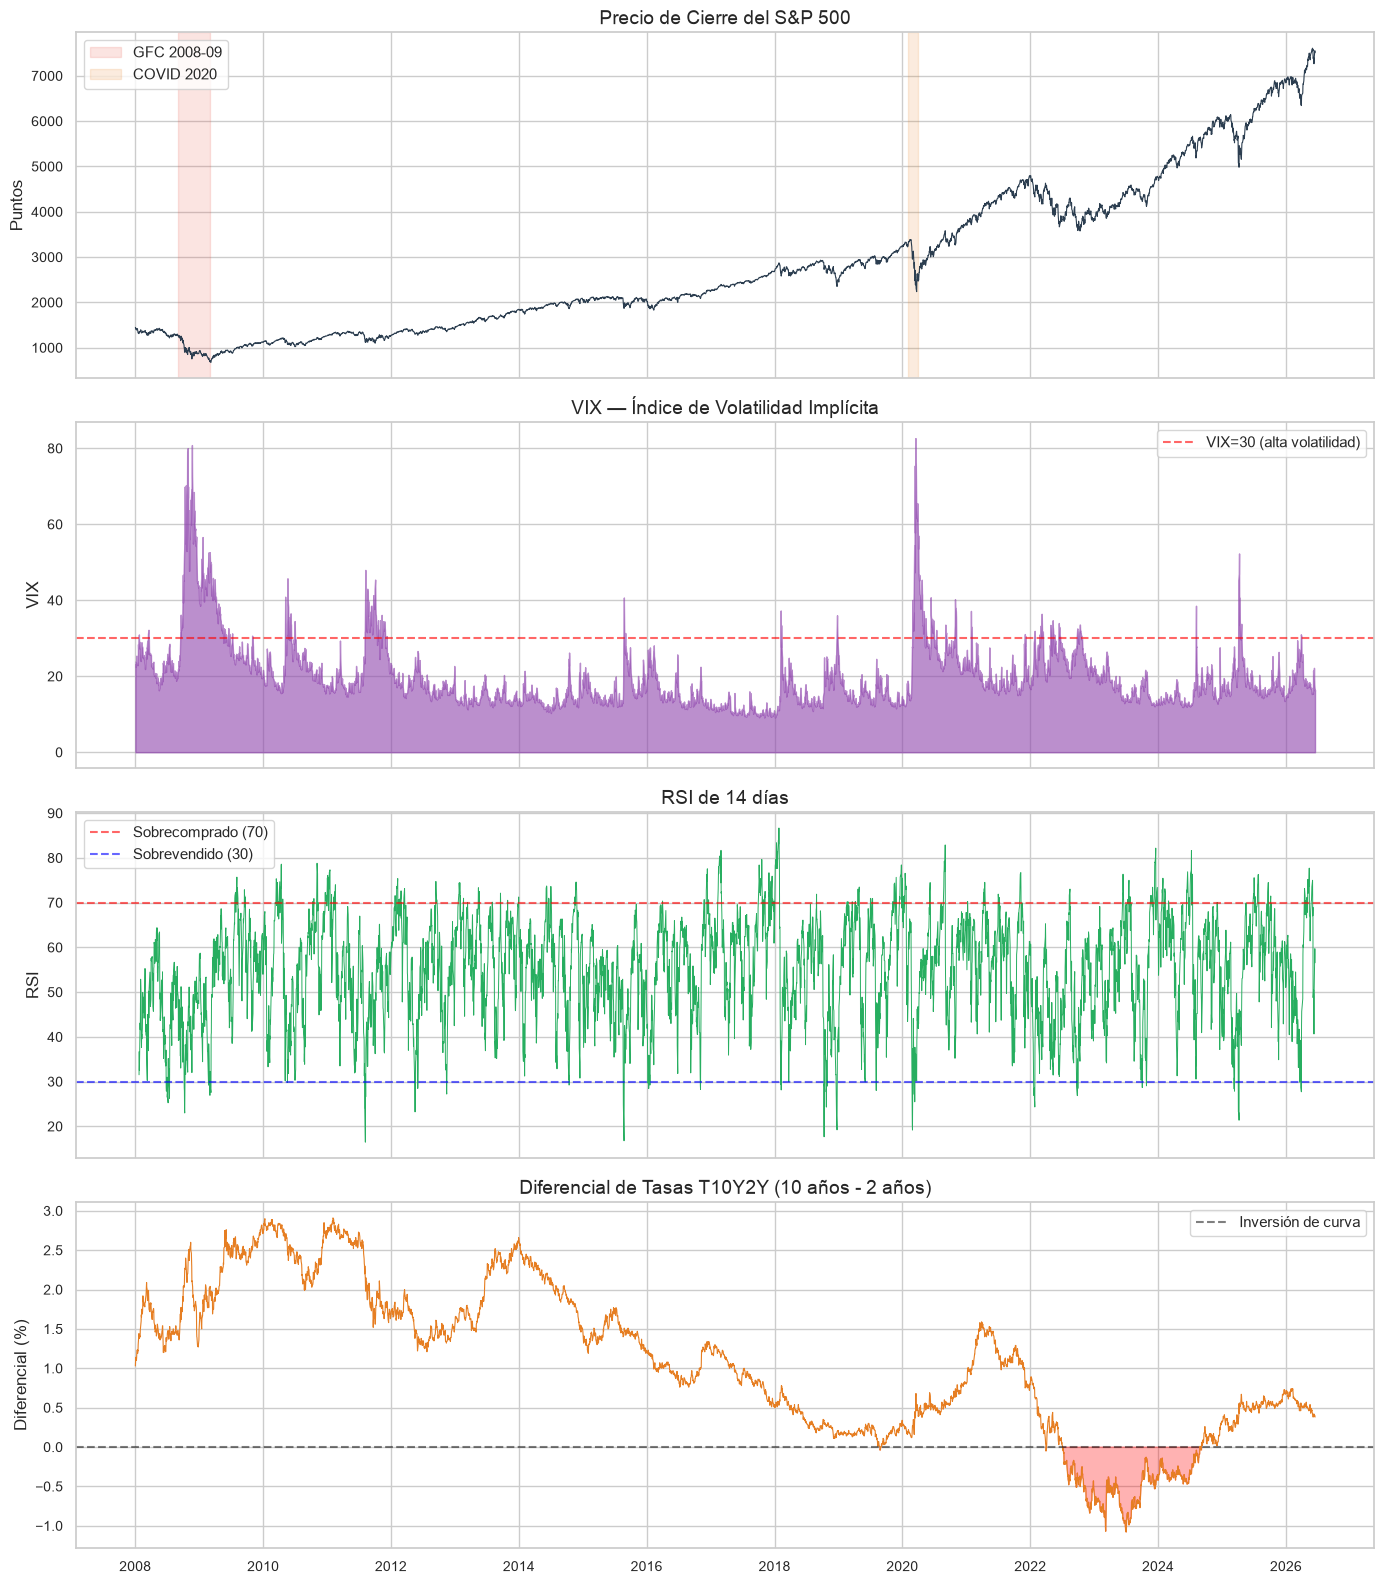

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

regimenes = [
    ("2008-09", "2009-03", "GFC 2008-09", "#e74c3c"),
    ("2020-02", "2020-04", "COVID 2020", "#e67e22"),
]

def marcar_regimenes(ax):
    for inicio, fin, label, color in regimenes:
        ax.axvspan(pd.Timestamp(inicio), pd.Timestamp(fin), alpha=0.15, color=color, label=label)

# Precio de cierre
axes[0].plot(df.index, df["Close"], color="#2c3e50", linewidth=0.8)
marcar_regimenes(axes[0])
axes[0].set_title("Precio de Cierre del S&P 500")
axes[0].set_ylabel("Puntos")
axes[0].legend(loc="upper left")

# VIX
axes[1].fill_between(df.index, df["vix"], alpha=0.6, color="#8e44ad")
axes[1].axhline(30, color="red", linestyle="--", alpha=0.6, label="VIX=30 (alta volatilidad)")
axes[1].set_title("VIX — Índice de Volatilidad Implícita")
axes[1].set_ylabel("VIX")
axes[1].legend()

# RSI
axes[2].plot(df.index, df["RSI_14"], color="#27ae60", linewidth=0.7)
axes[2].axhline(70, color="red", linestyle="--", alpha=0.6, label="Sobrecomprado (70)")
axes[2].axhline(30, color="blue", linestyle="--", alpha=0.6, label="Sobrevendido (30)")
axes[2].set_title("RSI de 14 días")
axes[2].set_ylabel("RSI")
axes[2].legend()

# T10Y2Y (yield curve)
axes[3].plot(df.index, df["t10y2y"], color="#e67e22", linewidth=0.8)
axes[3].axhline(0, color="black", linestyle="--", alpha=0.5, label="Inversión de curva")
axes[3].fill_between(df.index, df["t10y2y"], 0,
                     where=(df["t10y2y"] < 0), alpha=0.3, color="red")
axes[3].set_title("Diferencial de Tasas T10Y2Y (10 años - 2 años)")
axes[3].set_ylabel("Diferencial (%)")
axes[3].legend()

axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.show()

## Distribución de las features

Analizamos la distribución de cada feature para detectar:
- **Asimetría extrema** — podría indicar outliers que afecten el modelado
- **Multimodalidad** — podría indicar distintos regímenes de mercado
- **Escala** — los modelos basados en distancias (LR, MLP) son sensibles a la escala; XGBoost no lo es

El StandardScaler que aplicamos antes de LR y MLP normaliza las distribuciones a media 0 y varianza 1, mitigando los problemas de escala.

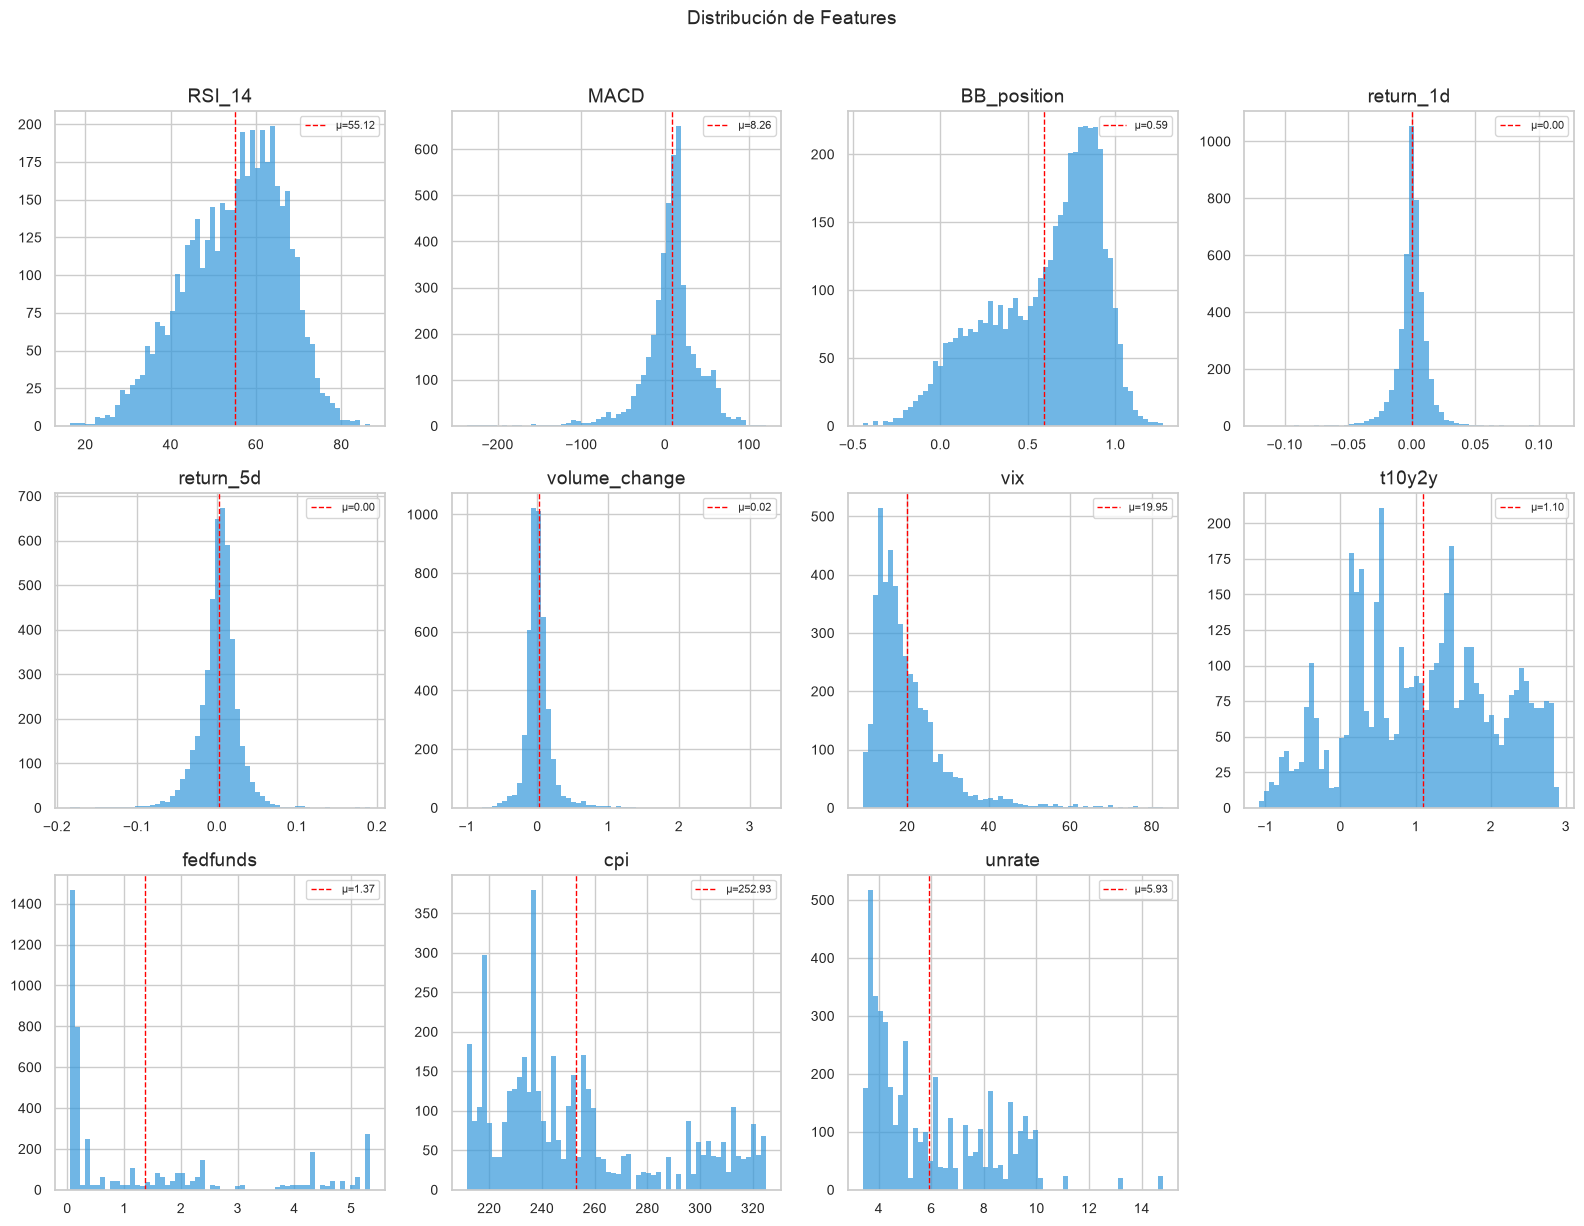

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    data = df[col].dropna()
    axes[i].hist(data, bins=60, edgecolor="none", color="#3498db", alpha=0.7)
    axes[i].axvline(data.mean(), color="red", linestyle="--", linewidth=1, label=f"μ={data.mean():.2f}")
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

# Ocultar subplot sobrante
for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de Features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Observaciones sobre las distribuciones de features

**Indicadores técnicos** (`RSI`, `MACD`, `return_1d`, `return_5d`, `volume_change`) 
muestran distribuciones aproximadamente normales y centradas en cero.

**Indicadores macroeconómicos** (`FEDFUNDS`, `CPI`, `UNRATE`, `T10Y2Y`, `VIX`) muestran 
distribuciones multimodales o sesgadas, lo cual es informativo en sí mismo:


**Implicación metodológica:** la heterogeneidad distribucional entre features técnicas y 
macroeconómicas justifica el uso de `StandardScaler` para el MLP (sensible a escala) pero 
no para XGBoost (invariante a monotransformaciones). Los modelos basados en árboles pueden 
explotar directamente la estructura multimodal de las variables macro como señales de régimen.

## Correlaciones entre features y con el target

La correlación de Pearson entre las features y el target nos da una primera señal de **cuáles features tienen poder predictivo**. En mercados financieros, esperamos correlaciones bajas (el mercado es difícil de predecir), lo que no significa que las features no sirvan — los modelos capturan combinaciones no-lineales.

La **multicolinealidad** entre features (CPI y FEDFUNDS, por ejemplo) no es un problema para XGBoost, pero puede inflar los coeficientes de Logistic Regression.

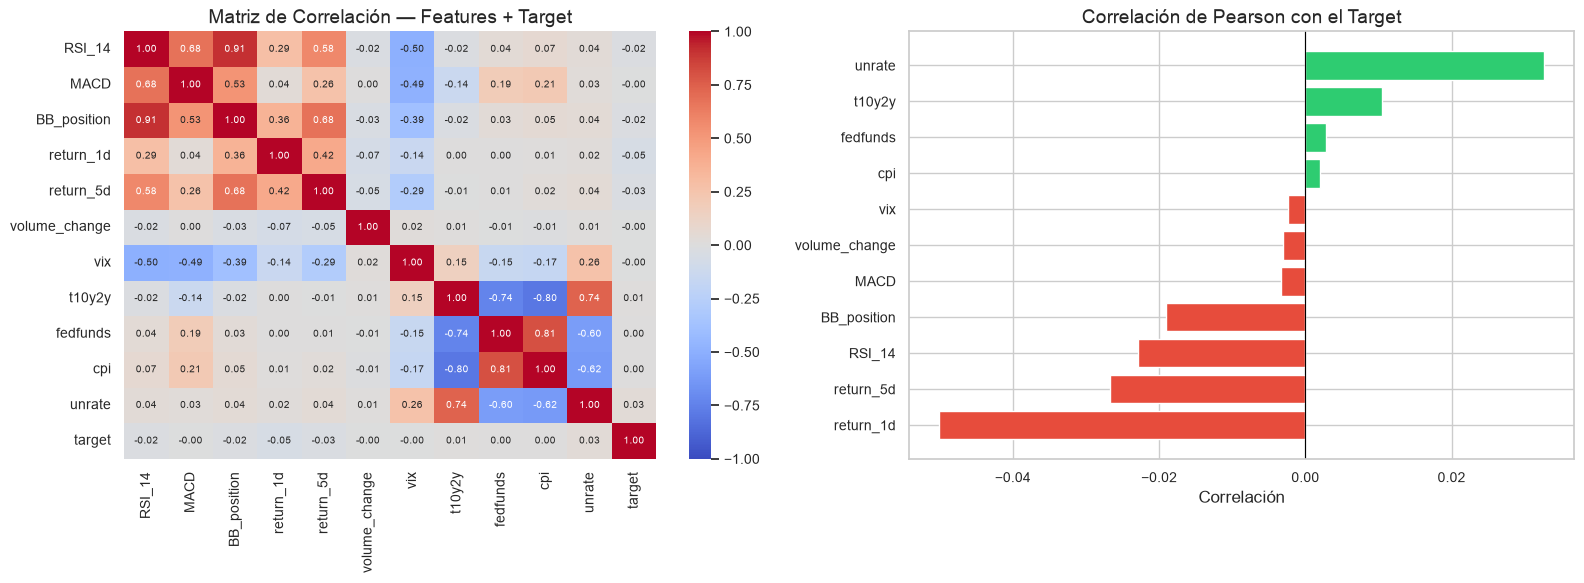


Top features por correlación absoluta con el target:
return_1d        0.050066
unrate           0.032610
return_5d        0.026677
RSI_14           0.022864
BB_position      0.019083
t10y2y           0.010429
MACD             0.003275
volume_change    0.003125
fedfunds         0.002820
vix              0.002387
cpi              0.001938


In [ ]:
cols_analisis = FEATURE_COLS + ["target"]
corr_matrix = df[cols_analisis].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap completo
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
    vmin=-1, vmax=1, ax=axes[0], annot_kws={"size": 7}
)
axes[0].set_title("Matriz de Correlación — Features + Target")

# Correlación de cada feature con el target
corr_target = corr_matrix["target"].drop("target").sort_values()
colores = ["#e74c3c" if v < 0 else "#2ecc71" for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=colores)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Correlación de Pearson con el Target")
axes[1].set_xlabel("Correlación")

plt.tight_layout()
plt.show()

print("\nTop features por correlación absoluta con el target:")
print(corr_target.abs().sort_values(ascending=False).to_string())

## Análisis por régimen de mercado

El mercado no se comporta igual en todos los períodos. Comparamos las estadísticas del target y los indicadores entre tres regímenes:

- **Crisis (2008-2009)**: contexto de alta volatilidad, mercado bajista
- **Bull market (2013-2019)**: mercado alcista con baja volatilidad
- **COVID (2020)**: caída abrupta y recuperación récord

Esto nos permite entender si los modelos podrán generalizar a distintos regímenes.

In [ ]:
regimenes_df = {
    "GFC 2008-09":       df["2008":"2009"],
    "Bull 2013-19":      df["2013":"2019"],
    "COVID 2020":        df["2020":"2020"],
    "Post-pandemia 22-24": df["2022":"2024"],
}

resumen = pd.DataFrame({
    nombre: {
        "% días positivos":   round(subdf["target"].mean() * 100, 1),
        "VIX promedio":       round(subdf["vix"].mean(), 1),
        "return_1d promedio": round(subdf["return_1d"].mean() * 100, 3),
        "RSI_14 promedio":    round(subdf["RSI_14"].mean(), 1),
        "Días en período":    len(subdf),
    }
    for nombre, subdf in regimenes_df.items()
}).T

print("Estadísticas por régimen de mercado:")
display(resumen)

Estadísticas por régimen de mercado:


,% días positivos,VIX promedio,return_1d promedio,RSI_14 promedio,Días en período
GFC 2008-09,52.9,32.1,-0.028,50.4,505.0
Bull 2013-19,54.8,14.9,0.050,56.3,1762.0
COVID 2020,56.9,29.3,0.083,56.5,253.0
Post-pandemia 22-24,51.4,19.4,0.034,54.3,753.0


## Conclusiones del EDA

**Lo que aprendimos:**

1. **El target está levemente desbalanceado** (~54.5% días positivos). No requiere técnicas agresivas de balanceo — alcanza con `class_weight='balanced'` y `scale_pos_weight`.

2. **La correlación linear individual features-target es baja** (< 0.10 en todos los casos). Esto es esperado ya que si hubiera correlaciones altas, el mercado no sería tan difícil de predecir. Los modelos no lineales como XGBoost capturan interacciones que la correlación de Pearson no ve.

3. **El VIX es la feature más volátil entre regímenes**: pasa de ~14 en el bull market a ~32 en crisis. Esto puede dificultar la generalización si el test set tiene un régimen de volatilidad diferente al entrenamiento.

4. **CPI y FEDFUNDS están correlacionados** entre sí (~0.8). No es un problema para XGBoost ni para el MLP, pero puede inflar la varianza de los coeficientes de Logistic Regression.